# What are Isomers ?
Isomers are compounds that have the same molecular formula but differ in the arrangement of their atoms.

# Why do chemists care?
Because changing the arrangement of atoms can completely change:

boiling point

melting point

smell

toxicity

biological activity

drug effectiveness

A tiny structural change can turn:

✅ a medicine
into
❌ a toxic compound.

# Classification of Isomers
A) Structural Isomers

B) Stereoisomers

# A) Structural Isomer

Structural isomers are compounds that have the same molecular formula but different atom connectivity.

Atoms are connected differently.
eg:

CH3-CH2-OH

and

CH3-O-CH3

Different connectivity.
    
Different molecule.

# B) Stereoisomers

Stereoisomers are compounds that have the same molecular formula and the same atom connectivity, but differ in the three-dimensional arrangement of atoms.
    
Only the 3D arrangement changes.
They are mirror images.

Where Does RDKit Come In?
RDKit is not just interested in which atoms are present.
It also needs to know:
Which atoms are connected?
Which carbon is chiral?
Which bond is cis or trans?
Is the molecule R or S?
Are these two molecules actually the same drug?
RDKit can answer all of these questions—but only if the stereochemistry is represented correctly.

# Types of Stereoisomers
A) Enantiomers 

B) Diastereomers

# A) Enantiomers

Two stereoisomers that are non-superimposable mirror images of each other are called enantiomers.

Mirror images.

Cannot overlap.

Example
Left hand
Right hand

# What are R and S Enantiomers?
When a molecule contains a chiral center, it can exist in two different three-dimensional arrangements called enantiomers. These two forms are designated as R or S based on the spatial arrangement of the groups attached to the chiral center.
The letters R and S are assigned using the Cahn–Ingold–Prelog (CIP) priority rules, which rank the four substituents attached to the chiral carbon according to atomic number.

R (Rectus) is a Latin word meaning right.

S (Sinister) is a Latin word meaning left.

These labels describe the configuration of the chiral center and do not indicate whether the molecule rotates plane-polarized light to the right or left.

# B) Distereomers

Diastereomers are stereoisomers that are not mirror images of each other and not identical.

Key Characteristics

Non-mirror images: Unlike enantiomers, they cannot be lined up by a simple mirror flip.

Multiple centers: They usually require two or more stereocenters or a double bond.

Different properties:They have distinct melting points, boiling points, and densities, making them easy to separate.

eg: Cis-trans Isomers

# Will RDKit know whether they are R or S?

Answer: No.
Why?

Because the SMILES doesn't tell RDKit anything about the 3D arrangement.

It only tells RDKit:

Carbon is connected to Carbon

Carbon is connected to Oxygen


It does not specify which side the OH group points.

# How does RDKit store stereochemistry?

RDKit uses Isomeric SMILES.
    
These include special symbols.

    @ 

    @@ 

    These indicate the stereochemical orientation around a chiral atom.

    @ and @@ describe the order of atoms in the SMILES string, not directly the CIP R/S designation.
Whether a chiral center is R or S depends on the CIP ( Cahn–Ingold–Prelog ) priority rules and the atom ordering in the SMILES.
RDKit can calculate the actual R/S assignment for you.

@ and @@ indicate that a chiral center has a defined stereochemical arrangement. They distinguish two opposite configurations around the same atom. RDKit later uses the Cahn–Ingold–Prelog (CIP) priority rules to determine whether that arrangement corresponds to an R or S configuration. Therefore, @ and @@ should not be interpreted directly as R and S.

In [2]:
# Example

from rdkit import Chem

mol = Chem.MolFromSmiles("C[C@H](O)C(=O)O")

In [3]:
print(Chem.MolToSmiles(mol))

C[C@H](O)C(=O)O


The stereochemistry is preserved because it was part of the input

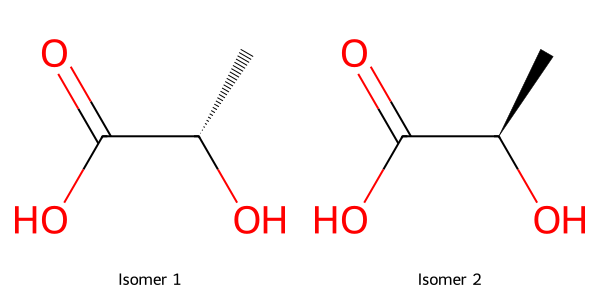

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw

# Two stereoisomers of lactic acid
mol1 = Chem.MolFromSmiles("C[C@H](O)C(=O)O")
mol2 = Chem.MolFromSmiles("C[C@@H](O)C(=O)O")

img = Draw.MolsToGridImage(
    [mol1, mol2],
    legends=["Isomer 1", "Isomer 2"],
    molsPerRow=2,
    subImgSize=(300,300)
)

img

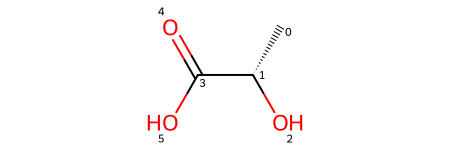

In [5]:
# number the atoms

from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = True

mol1

In [7]:
# let RDKit identify it 

Chem.FindMolChiralCenters(mol1, includeUnassigned=True)

[(1, 'S')]

# How does RDKit identify chiral centers?
# What is a Chiral Center?
A chiral center (also called a chiral carbon or stereocenter) is an atom, usually a carbon atom, that is bonded to four different substituent groups.
Because these four groups are different, the molecule can exist in two non-superimposable mirror-image forms, called enantiomers.
In organic chemistry, a chiral center is responsible for the three-dimensional arrangement of a molecule and plays an important role in determining its biological and pharmacological properties

Rule for Identifying a Chiral Center
A carbon atom is a chiral center if it satisfies all of the following conditions:

It is an sp³-hybridized carbon (tetrahedral carbon).

It is bonded to four different substituent groups.

None of the attached groups are identical.

If any two attached groups are the same, the carbon is not a chiral center.

# How does RDKit know this?
RDKit examines every atom in the molecule.
For each carbon atom, it asks:
Is this carbon tetrahedral?
Does it have four substituents?
Are all four substituents different?
If the answer is yes, RDKit marks it as a chiral center.

In [1]:
# Example

from rdkit import Chem

mol = Chem.MolFromSmiles("C[C@H](O)C(=O)O")

In [2]:
Chem.FindMolChiralCenters(
    mol,
    includeUnassigned=True
)

[(1, 'S')]

What does this mean?
It has two pieces of information.

1

This is the atom index.

The second atom (index 1) is chiral.

'S'

This is the CIP stereochemical assignment.

RDKit has determined that this chiral center has S configuration

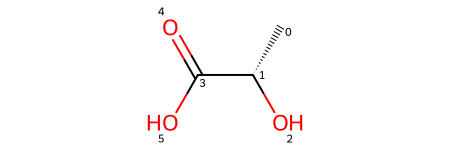

In [3]:
# Visualize the Atom Numbers

from rdkit.Chem.Draw import IPythonConsole

IPythonConsole.drawOptions.addAtomIndices = True

mol

Chem.FindMolChiralCenters()  is one of the most useful RDKit functions for stereochemistry because it can:

Identify all chiral centers in a molecule.

Report their atom indices.

Assign R/S configurations when stereochemistry is defined.

Detect potential chiral centers even when stereochemistry is unspecified.

# Example

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw

In [2]:
# Create Two Enantiomers

# Isomer A
mol1 = Chem.MolFromSmiles("C[C@H](O)C(=O)O")

# Isomer B
mol2 = Chem.MolFromSmiles("C[C@@H](O)C(=O)O")


In [ ]:
# Visualize Both Molecules

Draw.MolsToGridImage(
    [mol1, mol2],
    legends=["Isomer A (@)", "Isomer B (@@)"],
    molsPerRow=2,
    subImgSize=(300,300)
)

In [4]:
# Find Chiral Centers

print(Chem.FindMolChiralCenters(mol1))
print(Chem.FindMolChiralCenters(mol2))

[(1, 'S')]
[(1, 'R')]


In [5]:
# Verify Isomeric SMILES

print(Chem.MolToSmiles(mol1, isomericSmiles=True))
print(Chem.MolToSmiles(mol2, isomericSmiles=True))


C[C@H](O)C(=O)O
C[C@@H](O)C(=O)O


# Enumerating Stereoisomers in RDKit

# What is Stereoisomer Enumeration?
Stereoisomer enumeration is the process of automatically generating all possible stereoisomers of a molecule that contains one or more undefined chiral centers or double bonds with unspecified stereochemistry.
In other words, if a molecule has the potential to exist in multiple three-dimensional arrangements but its stereochemistry is not specified, stereoisomer enumeration generates every possible valid stereoisomer.

# Why is Stereoisomer Enumeration Important?

In drug discovery, the three-dimensional arrangement of atoms can significantly influence the biological activity of a molecule.
Different stereoisomers may exhibit different:

Binding affinity

Biological activity

Pharmacological effect

Toxicity

Metabolism

ADMET properties

Therefore, it is important to evaluate every possible stereoisomer rather than assuming they behave the same.
Stereoisomer enumeration ensures that all possible molecular configurations are generated and considered during computational studies.

In [7]:
# Example

from rdkit import Chem
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers
from rdkit.Chem import Draw

In [8]:
# Create Molecules

mol = Chem.MolFromSmiles("CC(O)C(=O)O")

In [9]:
# Enumerate Stereoisomer

isomers = list(EnumerateStereoisomers(mol))

In [10]:
# Check the Number of Isomers

print(len(isomers))

2


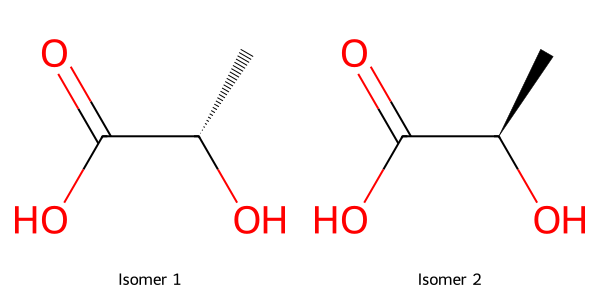

In [11]:
# Visualize the Isomers

Draw.MolsToGridImage(
    isomers,
    legends=[f"Isomer {i+1}" for i in range(len(isomers))],
    molsPerRow=2,
    subImgSize=(300,300)
)

In [12]:
# print Isomeric SMILES

for mol in isomers:
    print(Chem.MolToSmiles(mol, isomericSmiles=True))

C[C@H](O)C(=O)O
C[C@@H](O)C(=O)O


Applications in Cheminformatics

Stereoisomer enumeration is widely used in:

Drug discovery

Virtual screening

Molecular docking

QSAR modeling

ADMET prediction

Chemical library generation

Lead optimization